In [2]:

import pandas as pd

illegal = pd.read_csv('../resources/illegal_parking.csv')

In [3]:
illegal

,연번,단속일자,단속시간,단속장소,단속구분,데이터 기준일
0,1,2024-01-01,09:30:00,조치원역광장-버스정류장,고정형CCTV,2025-07-31
1,2,2024-01-01,11:37:00,조치원역광장-택시승강장,고정형CCTV,2025-07-31
2,3,2024-01-01,13:29:00,조치원역광장-택시승강장,고정형CCTV,2025-07-31
3,4,2024-01-01,14:59:00,해들마을6단지교차로주변,고정형CCTV,2025-07-31
4,5,2024-01-01,16:22:00,세종교육청앞삼거리,고정형CCTV,2025-07-31
...,...,...,...,...,...,...
127430,127431,2025-07-23,11:18:51,새샘마을3단지정문앞,고정형CCTV,2025-07-31
127431,127432,2025-07-23,15:17:21,고운동 고운뜰4길,주행형CCTV,2025-07-31
127432,127433,2025-07-24,13:05:54,새솔유치원-놀이터삼거리,고정형CCTV,2025-07-31
127433,127434,2025-07-24,15:04:15,조치원읍 죽림로 부근,주행형CCTV,2025-07-31


In [4]:
illegal[illegal['단속장소'].str.contains('D_Name', na=False)]

,연번,단속일자,단속시간,단속장소,단속구분,데이터 기준일
2917,2918,2024-01-24,17:14:00,D_Name 용포외곽길,주행형CCTV,2025-07-31
2918,2919,2024-01-24,17:14:00,D_Name 용포외곽길,주행형CCTV,2025-07-31
2919,2920,2024-01-24,17:15:00,D_Name 용포외곽길,주행형CCTV,2025-07-31
5980,5981,2024-01-24,17:13:00,D_Name 용포외곽길,주행형CCTV,2025-07-31
5981,5982,2024-01-24,17:14:00,D_Name 대평시장2길,주행형CCTV,2025-07-31
...,...,...,...,...,...,...
92134,92135,2025-02-20,10:11:17,D_Name 용포외곽길,주행형CCTV,2025-07-31
92135,92136,2025-02-20,15:32:14,D_Name 명학산단로,주행형CCTV,2025-07-31
92136,92137,2025-02-20,15:32:19,D_Name 명학산단로,주행형CCTV,2025-07-31
93649,93650,2025-02-24,09:40:18,D_Name 부강금호로,주행형CCTV,2025-07-31


In [5]:
region_map = {
    '한솔': '한솔동',
    '새롬': '새롬동',
    '나성': '나성동',
    '다정': '다정동',
    '도담': '도담동',
    '어진': '어진동',
    '해밀': '해밀동',
    '아름': '아름동',
    '종촌': '종촌동',
    '고운': '고운동',
    '보람': '보람동',
    '대평': '대평동',
    '소담': '소담동',
    '반곡': '반곡동',
    '가람': '가람동',
    
    '용포외곽길':'금남면',
    '세종시립도서관':'고운동',
    '세종교육청':'보람동',
    '새샘':'소담동',
    '새솔유치원':'다정동',
    '해들':'대평동',
    '범지기':'아름동',
    '새뜸':'새롬동',
    '가온':'다정동',
    '보건복지부':'어진동',
    '코스트코':'대평동',
    '국민은행첫마을지점':'나성동',
    '축산물품질평가원':'아름동',
    '국민권익위원회':'어진동',
    '호려울마을4단지':'보람동',
    '명동초':'조치원읍',
    '대영프라자':'아름동',
    '가재마을5단지':'종촌동',
    '대수약국':'조치원읍',
    '에반아트리움':'나성동',
    '어반아트리움':'나성동',
    '보건환경연구원':'조치원읍',
    '수루배마을':'반곡동',
    '호려울마을':'보람동',
    '나릿재':'나성동',
    '행정안전부':'어진동',
    '첫마을':'한솔동',
    '새나루':'집현동',
    '도시통합정보센터':'조치원읍',
    '삼일아파트':'조치원읍',
    '도램마을':'도담동',
    '센트럴타워':'나성동',
    '원리119':'조치원읍',
    '국무총리':'어진동',
    '한결초':'다정동',
    '온빛초':'고운동',
    '농림축산식품부':'어진동',
    '정부청사':'어진동',
    '양지':'도담동',
    '가재':'종촌동',
    '두루':'고운동',
    '봉암자율방범대':'연서면',
    '늘봄초등학교':'도담동',
    '여울초':'보람동',
    '한뜰마을':'어진동',
    '가락마을':'고운동',
    '성프란치스코성당':'고운동',
    '마크원에비뉴':'나성동',
    '연남초':'연기면',
    '도원초':'연서면',
    '가락유치원':'고운동',
    '백두산빌딩':'종촌동',
    '국세청':'나성동',
    '교동초':'조치원읍',
    '나래초':'아름동',
    '참샘유치원':'한솔동',
    '금강프라자':'나성동',
    '산업통상자원부':'어진동',
    '신봉초등학교':'조치원읍',
    '엠브릿지사거리':'어진동',
    '명학리 978':'연동면',
    '치원읍':'조치원읍',
    '명학산단로':'연동면',
    '명학산단서로':'연동면',
    '명학산단남로':'연동면',
    '명학산단1로':'연동면',
    '원합강1길':'연동면',
    '발산1길':'금남면',
    '부촌길':'부강면',
    '용포중앙2길':'금남면',
    '퇴미로':'부강면',

    '산울': '산울동',
    '집현': '집현동',
    '세종': '세종동',
    '한별': '한별동',

    '조치원': '조치원읍',

    '연기': '연기면',
    '연동': '연동면',
    '부강': '부강면',
    '금남': '금남면',
    '장군': '장군면',
    '연서': '연서면',
    '전의': '전의면',
    '전동': '전동면',
    '소정': '소정면'
}

In [6]:
def classify_region(place):
    place = str(place)

    for keyword, region in region_map.items():
        if keyword in place:
            return region

    return '미분류'

In [7]:
illegal['지역'] = illegal['단속장소'].apply(classify_region)
illegal

,연번,단속일자,단속시간,단속장소,단속구분,데이터 기준일,지역
0,1,2024-01-01,09:30:00,조치원역광장-버스정류장,고정형CCTV,2025-07-31,조치원읍
1,2,2024-01-01,11:37:00,조치원역광장-택시승강장,고정형CCTV,2025-07-31,조치원읍
2,3,2024-01-01,13:29:00,조치원역광장-택시승강장,고정형CCTV,2025-07-31,조치원읍
3,4,2024-01-01,14:59:00,해들마을6단지교차로주변,고정형CCTV,2025-07-31,대평동
4,5,2024-01-01,16:22:00,세종교육청앞삼거리,고정형CCTV,2025-07-31,보람동
...,...,...,...,...,...,...,...
127430,127431,2025-07-23,11:18:51,새샘마을3단지정문앞,고정형CCTV,2025-07-31,소담동
127431,127432,2025-07-23,15:17:21,고운동 고운뜰4길,주행형CCTV,2025-07-31,고운동
127432,127433,2025-07-24,13:05:54,새솔유치원-놀이터삼거리,고정형CCTV,2025-07-31,다정동
127433,127434,2025-07-24,15:04:15,조치원읍 죽림로 부근,주행형CCTV,2025-07-31,조치원읍


In [8]:
#미분류 행 몇개
(illegal['지역'] == '미분류').sum()

1132

In [9]:
unclassified = illegal[illegal['지역'] == '미분류']
unclassified['단속장소'].value_counts()

단속장소
제일풍경채 주변    914
복지회관앞5거리    218
Name: count, dtype: int64

In [10]:
#미분류 된 데이터 삭제
illegal = illegal[illegal['지역'] != '미분류']


In [11]:
#어느 동이 주차단속이 많을까

illegal['지역'].value_counts()

지역
조치원읍    28321
고운동     15164
어진동     11016
아름동     10572
나성동      9780
다정동      8908
새롬동      7922
도담동      4480
대평동      4065
보람동      3352
세종동      3194
소담동      3086
해밀동      2748
한솔동      2308
집현동      2265
반곡동      1935
소정면      1627
종촌동      1547
금남면      1219
연동면       944
부강면       578
연서면       418
산울동       389
전의면       210
연기면       138
장군면        50
전동면        35
가람동        30
한별동         2
Name: count, dtype: int64

In [12]:
region_count_df = illegal['지역'].value_counts().reset_index()

region_count_df.columns = ['지역', '단속건수']

region_count_df

,지역,단속건수
0,조치원읍,28321
1,고운동,15164
2,어진동,11016
3,아름동,10572
4,나성동,9780
5,다정동,8908
6,새롬동,7922
7,도담동,4480
8,대평동,4065
9,보람동,3352


In [13]:
illegal

,연번,단속일자,단속시간,단속장소,단속구분,데이터 기준일,지역
0,1,2024-01-01,09:30:00,조치원역광장-버스정류장,고정형CCTV,2025-07-31,조치원읍
1,2,2024-01-01,11:37:00,조치원역광장-택시승강장,고정형CCTV,2025-07-31,조치원읍
2,3,2024-01-01,13:29:00,조치원역광장-택시승강장,고정형CCTV,2025-07-31,조치원읍
3,4,2024-01-01,14:59:00,해들마을6단지교차로주변,고정형CCTV,2025-07-31,대평동
4,5,2024-01-01,16:22:00,세종교육청앞삼거리,고정형CCTV,2025-07-31,보람동
...,...,...,...,...,...,...,...
127430,127431,2025-07-23,11:18:51,새샘마을3단지정문앞,고정형CCTV,2025-07-31,소담동
127431,127432,2025-07-23,15:17:21,고운동 고운뜰4길,주행형CCTV,2025-07-31,고운동
127432,127433,2025-07-24,13:05:54,새솔유치원-놀이터삼거리,고정형CCTV,2025-07-31,다정동
127433,127434,2025-07-24,15:04:15,조치원읍 죽림로 부근,주행형CCTV,2025-07-31,조치원읍


In [14]:
import plotly.express as px

region_df = illegal['지역'].value_counts().reset_index()
region_df.columns = ['지역', '단속건수']

fig = px.bar(
    region_df,
    x='지역',
    y='단속건수',
    text='단속건수',
    title='전체 지역별 불법주정차 단속 건수'
)

fig.update_layout(
    xaxis_title='지역',
    yaxis_title='단속 건수',
    xaxis_tickangle=-45,
    width=1200,
    height=600
)

fig.show()

In [19]:
area = pd.read_excel('../resources/세종시_동별_면적.xlsx')
area

,지역,면적
0,한솔동,2.70
1,새롬동,1.49
2,나성동,24.91
3,다정동,1.70
4,도담동,2.03
5,어진동,2.65
6,해밀동,8.44
7,아름동,2.19
8,종촌동,1.15
9,고운동,5.35


In [20]:
merged_df = pd.merge(
    region_count_df,
    area,
    on='지역'
)

merged_df['면적 당 단속건수'] = (
    merged_df['단속건수'] / merged_df['면적']
).round(0).astype(int)

merged_df



,지역,단속건수,면적,면적 당 단속건수
0,조치원읍,28321,13.56,2089
1,고운동,15164,5.35,2834
2,어진동,11016,2.65,4157
3,아름동,10572,2.19,4827
4,나성동,9780,24.91,393
5,다정동,8908,1.70,5240
6,새롬동,7922,1.49,5317
7,도담동,4480,2.03,2207
8,대평동,4065,1.50,2710
9,보람동,3352,1.33,2520


In [21]:
merged_df = merged_df.sort_values(
    by='면적 당 단속건수',
    ascending=False
)

merged_df

,지역,단속건수,면적,면적 당 단속건수
6,새롬동,7922,1.49,5317
5,다정동,8908,1.70,5240
3,아름동,10572,2.19,4827
2,어진동,11016,2.65,4157
1,고운동,15164,5.35,2834
8,대평동,4065,1.50,2710
11,소담동,3086,1.17,2638
9,보람동,3352,1.33,2520
7,도담동,4480,2.03,2207
0,조치원읍,28321,13.56,2089


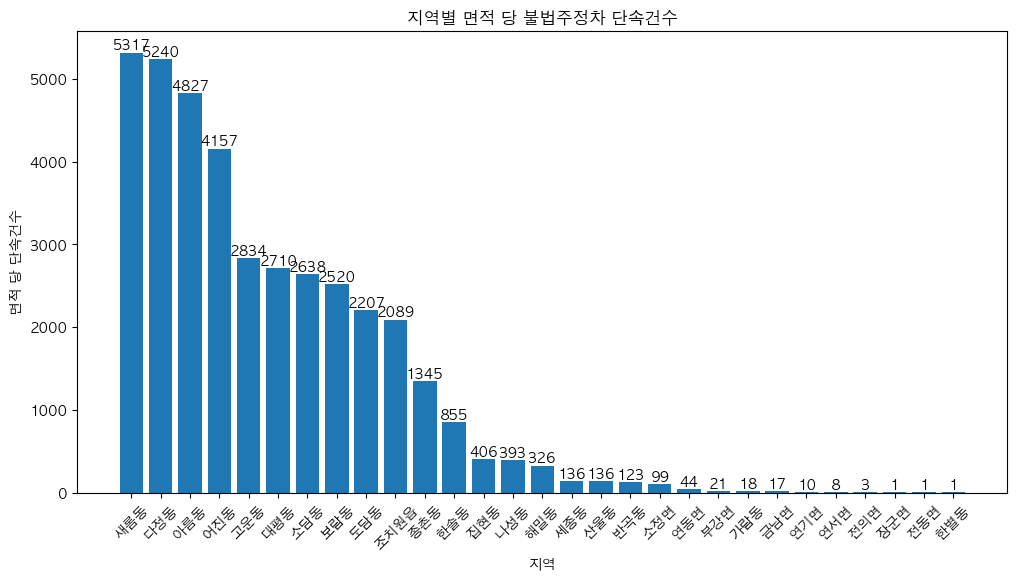

In [22]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))

bars = plt.bar(
    merged_df['지역'],
    merged_df['면적 당 단속건수']
)

plt.title('지역별 면적 당 불법주정차 단속건수')
plt.xlabel('지역')
plt.ylabel('면적 당 단속건수')

# 막대 위 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.show()

In [23]:
merged_df.to_csv('../resources/illegal_summary.csv', index=False, encoding='utf-8-sig')

In [ ]:
# 아름동,조치원읍,도담동,소담동,보람동,나성동,한솔동만 뽑음
target_regions = ['아름동', '조치원읍', '도담동', '소담동', '보람동', '나성동', '한솔동']

illegal_selected = illegal[illegal['지역'].isin(target_regions)]
illegal_selected['지역'].value_counts()
illegal_selected

,연번,단속일자,단속시간,단속장소,단속구분,데이터 기준일,지역
0,1,2024-01-01,09:30:00,조치원역광장-버스정류장,고정형CCTV,2025-07-31,조치원읍
1,2,2024-01-01,11:37:00,조치원역광장-택시승강장,고정형CCTV,2025-07-31,조치원읍
2,3,2024-01-01,13:29:00,조치원역광장-택시승강장,고정형CCTV,2025-07-31,조치원읍
3,4,2024-01-01,14:59:00,해들마을6단지교차로주변,고정형CCTV,2025-07-31,대평동
4,5,2024-01-01,16:22:00,세종교육청앞삼거리,고정형CCTV,2025-07-31,보람동
...,...,...,...,...,...,...,...
127430,127431,2025-07-23,11:18:51,새샘마을3단지정문앞,고정형CCTV,2025-07-31,소담동
127431,127432,2025-07-23,15:17:21,고운동 고운뜰4길,주행형CCTV,2025-07-31,고운동
127432,127433,2025-07-24,13:05:54,새솔유치원-놀이터삼거리,고정형CCTV,2025-07-31,다정동
127433,127434,2025-07-24,15:04:15,조치원읍 죽림로 부근,주행형CCTV,2025-07-31,조치원읍


In [ ]:
top_places_count = (
    illegal_selected
    .groupby('지역')['단속장소']
    .apply(lambda x: x.value_counts().head(1))
)

top_places_count

지역                
나성동   국민은행첫마을지점       1709
도담동   도담동 먹자골목인근      1580
보람동   호려울마을4단지앞사거리     923
소담동   새샘마을3단지정문앞       736
아름동   축산물품질평가원 삼거리    3292
조치원읍  조치원역광장-버스정류장    2658
한솔동   한솔파출소            536
Name: 단속장소, dtype: int64